In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import numpy as np
from matplotlib import pyplot as plt

import pint, logging
pint.logging.setup(level="ERROR")
logging.getLogger('enterprise').setLevel(logging.ERROR)

from pint.fitter import Fitter
from pint.models import get_model, get_model_and_toas
from pint.residuals import Residuals
from pint.simulation import make_fake_toas_uniform

from astropy import units as u
from copy import deepcopy
from tqdm import tqdm

path = '../../datasets/NG15'

In [2]:
# Choose one pulsar to test on
par = path +'/par/J0740+6620_PINT_DMX.par'
tim = path +'/tim/J0740+6620_PINT_DMX.tim'

model, toas = get_model_and_toas(par, tim)
fit = pint.fitter.Fitter.auto(toas, model)
fit.fit_toas()
M, labels, units = fit.get_designmatrix()
fit_values = np.array([0]+[fit.model[l].value for l in labels[1:]])
fit_uncert = np.array([1]+[fit.model[l].uncertainty_value for l in labels[1:]])


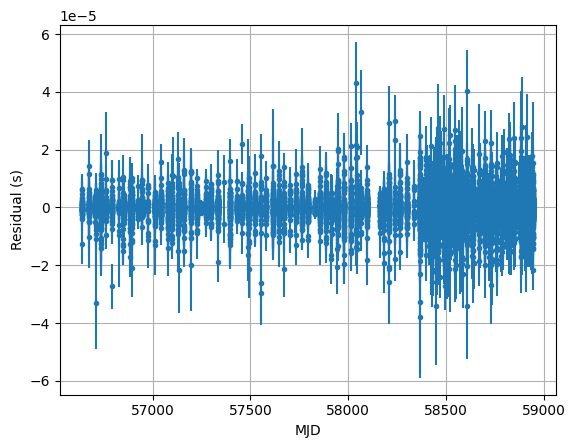

In [3]:
residuals = Residuals(fit.toas, fit.model)

toas = fit.toas.get_mjds().value
r = residuals.time_resids.to(u.s).value
sigma = residuals.toas.get_errors().to(u.s).value
ntoa = len(toas)


plt.errorbar(toas, r, yerr=sigma, fmt=".")
plt.xlabel("MJD")
plt.ylabel("Residual (s)")
plt.grid()
plt.show()

ELONG


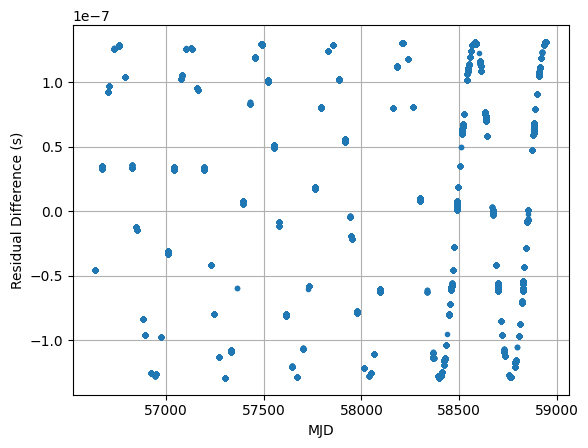

In [4]:
def perturb_deterministic_model(label, epsilon):
    dmodel = deepcopy(fit.model)

    dval = dmodel[label].value * np.asarray(epsilon).item()
    dmodel[label].value += dval

    dres = Residuals(fit.toas, dmodel)
    r = dres.time_resids.to(u.s).value

    return r

def perturb_linear_model(label, epsilon):
    idx = labels.index(label)

    dval = fit.model[label].value * np.asarray(epsilon).item()
    r = residuals.time_resids.to(u.s).value + dval * M[:,idx]

    return r

def q_statistic(label, epsilon):
    dr = perturb_deterministic_model(label, epsilon)
    lr = perturb_linear_model(label, epsilon)
    Q = np.sum(( (dr-lr)/sigma )**2)/ntoa
    return Q


l = labels[2]
print(l)
dr = perturb_deterministic_model(l, 1e-10)
lr = perturb_linear_model(l, 1e-10)

plt.plot(residuals.toas.get_mjds(), dr-lr, ".")
plt.xlabel("MJD")
plt.ylabel("Residual Difference (s)")
plt.grid()
plt.show()

In [5]:
Q = q_statistic(l, -1.5e-9)
Q

np.longdouble('1.0248791590230799651')

If Q is less than 1, then the noise in the linear approximation is less than the noise in the residuals, and the linear approximation is valid. If Q is greater than 1, then the noise in the linear approximation is greater than the noise in the residuals, and the linear approximation is not valid.

In [6]:
from scipy.optimize import brentq


def find_epsilon(label, x0, q_target=1):
    foo = lambda x: q_statistic(label, x) - q_target
    # We know that using x=0 gives Q=0 -> foo(0) = -q_target
    # need to find x0 which gives Q>q_target -> foo(x) > 0
    max_iter = 20
    for i in range(max_iter): # To span 20 orders of magnitude
        if foo(x0) > 0:
            break
        else:
            x0 *= 10 # Increase by an order of magnitude until we find a value that gives Q>q_target

        if i == max_iter - 1:
            raise ValueError("Failed to find an x0 that gives Q > q_target")

    # Now we have a bracket for the root, we can use brentq to find the root
    epsilon = brentq(foo, 0, x0) # Epsilon where Q approx 1
    return epsilon


# For each parameter, find the negative and positive epsilon with Q=1
epsilons = np.zeros((len(labels),2)) # negative, positive
for i in tqdm(range(len(labels))):
    if i==0:
        continue # skip the offset parameter
    l = labels[i]

    try:
        eps_n = find_epsilon(l, x0=-fit_uncert[i])
        eps_p = find_epsilon(l, x0=-1.1*eps_n) # use the negative epsilon as a guess!
    except ValueError:
        eps_n = np.nan
        eps_p = np.nan

    epsilons[i] = [eps_n, eps_p]

    

  0%|          | 0/129 [00:00<?, ?it/s]

100%|██████████| 129/129 [57:57<00:00, 26.96s/it]


In [7]:
print('TM param \t epsilon \t z-score \t theta')
for i,l in enumerate(labels):
    if i==0:
        continue
    print(l, epsilons[i], epsilons[i]/sigma[i], fit.model[l].value + epsilons[i])

TM param 	 epsilon 	 z-score 	 theta
PX [-1.23490658  1.2349065 ] [-196266.14481012  196266.13168106] [-0.11577451  2.35403857]
ELONG [-1.48169342e-09  1.48171187e-09] [-0.00031452  0.00031452] [103.75913534 103.75913535]
ELAT [-3.69287728e-09  3.69293676e-09] [-0.00100024  0.00100025] [44.1024787 44.1024787]
PMELONG [-0.06705139  0.06705141] [-18456.20553685  18456.20942788] [-2.79980764 -2.66570484]
PMELAT [-0.00859395  0.00859395] [-2272.32903102  2272.32942114] [-32.48840403 -32.47121613]
F0 [nan nan] [nan nan] [nan nan]
F1 [-9.39753509e-05  9.39753696e-05] [-8.80001413  8.80001588] [-9.39753509e-05  9.39753696e-05]
DMX_0001 [-4.12072065  4.12072097] [-324977.96944698  324977.99419027] [-4.12198482  4.1194568 ]
DMX_0002 [-3.8556278  3.8556276] [-657059.95299303  657059.91765964] [-3.85667644  3.85457897]
DMX_0003 [-4.88063028  4.88062993] [-1594456.15259494  1594456.03703114] [-4.88145485  4.87980536]
DMX_0004 [-8.2010377   8.20103756] [-2788520.1283374   2788520.08242057] [-8.2021

TM param 	 epsilon 	 z-score 	 theta
PX [-1.23490658  1.2349065 ] [-196266.14481012  196266.13168106] [-0.11577451  2.35403857]
ELONG [-1.48169342e-09  1.48171187e-09] [-0.00031452  0.00031452] [103.75913534 103.75913535]
ELAT [-3.69287728e-09  3.69293676e-09] [-0.00100024  0.00100025] [44.1024787 44.1024787]
PMELONG [-0.06705139  0.06705141] [-18456.20553685  18456.20942788] [-2.79980764 -2.66570484]
PMELAT [-0.00859395  0.00859395] [-2272.32903102  2272.32942114] [-32.48840403 -32.47121613]
F0 [nan nan] [nan nan] [nan nan]
F1 [-9.39753509e-05  9.39753696e-05] [-8.80001413  8.80001588] [-9.39753509e-05  9.39753696e-05]
DMX_0001 [-4.12072065  4.12072097] [-324977.96944698  324977.99419027] [-4.12198482  4.1194568 ]
DMX_0002 [-3.8556278  3.8556276] [-657059.95299303  657059.91765964] [-3.85667644  3.85457897]
DMX_0003 [-4.88063028  4.88062993] [-1594456.15259494  1594456.03703114] [-4.88145485  4.87980536]
DMX_0004 [-8.2010377   8.20103756] [-2788520.1283374   2788520.08242057] [-8.20213658  8.19993868]
DMX_0005 [-1.16856498  1.16856465] [-206972.18973644  206972.13030172] [-1.16944626  1.16768337]
DMX_0006 [-9.22683251  9.22683292] [-2259816.92647917  2259817.02600173] [-9.22781336  9.22585207]
DMX_0007 [-0.87548591  0.87548592] [-183655.53011788  183655.53233064] [-0.87641126  0.87456057]
DMX_0008 [-3.81206793  3.81206829] [-622175.27772606  622175.33692952] [-3.81296993  3.81116629]
DMX_0009 [-0.96172732  0.96172738] [-199074.1716347   199074.18409264] [-0.96263885  0.96081586]
DMX_0010 [-5.77872894  5.77872883] [-1151141.22388307  1151141.20092032] [-5.77959491  5.77786286]
DMX_0011 [-4.22775612  4.22775628] [-1068964.88544783  1068964.92439454] [-4.22888413  4.22662827]
DMX_0012 [-1.16476074  1.16476091] [-226211.05927655  226211.09231916] [-1.16567912  1.16384254]
DMX_0013 [-23.74834362  23.74834406] [-4135901.01364341  4135901.08980331] [-23.74885943  23.74782825]
DMX_0014 [-1.70579334  1.70579352] [-320036.27388744  320036.30703008] [-1.70669266  1.7048942 ]
DMX_0015 [-4.39057108  4.39057083] [-872010.14547459  872010.09577334] [-4.39161392  4.38952799]
DMX_0016 [-6.24232478  6.24232482] [-1263117.11430868  1263117.12308308] [-6.24340089  6.24124871]
DMX_0017 [-12.53676497  12.53676497] [-2379344.27259363  2379344.27192184] [-12.53788962  12.53564033]
DMX_0018 [-4.16131521  4.16131529] [-510277.76997169  510277.77883915] [-4.16218306  4.16044744]
DMX_0019 [-2.30037395  2.30037389] [-319318.9819817   319318.97418042] [-2.30123685  2.29951098]
DMX_0020 [-3.38820282  3.38820278] [-962831.1497419   962831.14059295] [-3.38903369  3.38737191]
DMX_0021 [-7.76540155  7.76540198] [-2010199.72784569  2010199.83843026] [-7.76635442  7.76444911]
DMX_0022 [-4.20775104  4.20775011] [-743813.15956797  743812.99480979] [-4.20831298  4.20718818]
DMX_0023 [-26.13320063  26.1332011 ] [-10349782.42748506  10349782.61536794] [-26.13372808  26.13267365]
DMX_0024 [-6.26967212  6.26967255] [-1218595.16400814  1218595.24789829] [-6.27051494  6.26882973]
DMX_0025 [-1.08628064  1.08628054] [-361972.8876785   361972.85652824] [-1.08705191  1.08550927]
DMX_0026 [-39.6967819   39.69678199] [-8757286.98456188  8757287.00422081] [-39.6956202   39.69794369]
DMX_0027 [-4.83080188  4.83080183] [-2671903.69204448  2671903.66813103] [-4.83168609  4.82991761]
DMX_0028 [-6.67324067  6.6732407 ] [-3861829.0927424   3861829.10733711] [-6.67392072  6.67256065]
DMX_0029 [-3.56005832  3.56005829] [-2264668.14528985  2264668.12325901] [-3.56079326  3.55932335]
DMX_0030 [-7.5137747  7.5137747] [-4743544.63294107  4743544.63349629] [-7.51443459  7.51311481]
DMX_0031 [-6.1343668   6.13436683] [-3056485.69875348  3056485.71427348] [-6.1349604   6.13377322]
DMX_0032 [-2.87085673  2.87085696] [-1324195.90760539  1324196.01423822] [-2.87144298  2.87027071]
DMX_0033 [-8.57482935  8.57482941] [-3859059.11319836  3859059.1394771 ] [-8.57551896  8.5741398 ]
DMX_0034 [-8.21679818  8.21679816] [-3380007.47905528  3380007.47034708] [-8.21732274  8.21627361]
DMX_0035 [-9.26836154  9.26836158] [-2892747.0471952   2892747.06030275] [-9.2689403   9.26778282]
DMX_0036 [-7.28645536  7.28645538] [-2096821.68694569  2096821.69176254] [-7.28712359  7.28578715]
DMX_0037 [-9.12149078  9.12149073] [-3783281.12023303  3783281.09865111] [-9.1222612   9.12072031]
DMX_0038 [-6.00681328  6.00681327] [-2183501.73594939  2183501.73232262] [-6.00731911  6.00630743]
DMX_0039 [-3.95776207  3.95776209] [-1392597.49260582  1392597.49751998] [-3.95820033  3.95732383]
DMX_0040 [-3.02747227  3.02747227] [-1277953.68043658  1277953.68001979] [-3.02797957  3.02696497]
DMX_0041 [-2.48146487  2.4814649 ] [-864923.27308116  864923.28212011] [-2.48182312  2.48110665]
DMX_0042 [-9.16750364  9.16750366] [-2215443.12308277  2215443.12806805] [-9.16778844  9.16721887]
DMX_0043 [-30.70289043  30.70289043] [-9222856.8428951   9222856.84170364] [-30.70309533  30.70268553]
DMX_0044 [-5.65252356  5.65252361] [-763854.53472374  763854.54210205] [-5.65278219  5.65226497]
DMX_0045 [-27.58060207  27.5806019 ] [-5010100.28465654  5010100.25413908] [-27.58106264  27.58014133]
DMX_0046 [-52.85964092  52.85964079] [-10273982.68684331  10273982.66023942] [-52.85976822  52.85951349]
DMX_0047 [-71.2784025   71.27840266] [-13686329.20530566  13686329.23524664] [-71.27852302  71.27828214]
DMX_0048 [-30.55140427  30.55140409] [-3964625.52149128  3964625.49774674] [-30.55156277  30.55124558]
DMX_0049 [-12.11135031  12.11135031] [-4026379.75875313  4026379.75655877] [-12.11154879  12.11115183]
DMX_0050 [-29.46075593  29.46075595] [-6635305.388691    6635305.39423862] [-29.46097401  29.46053787]
DMX_0051 [-10.03287473  10.03287515] [-2668317.74732352  2668317.85833253] [-10.03276439  10.03298548]
DMX_0052 [-44.61327161  44.6132714 ] [-7434306.21792641  7434306.18197134] [-44.61306236  44.61348065]
DMX_0053 [-2.21189972  2.21189962] [-440091.46889153  440091.44862164] [-2.21162508  2.21217426]
DMX_0054 [-13.46089127  13.46089143] [-3847068.09595924  3847068.14113151] [-13.46064328  13.46113942]
DMX_0055 [-17.27002598  17.27002605] [-3388272.70634304  3388272.71861146] [-17.26944391  17.27060812]
DMX_0056 [-5.82418268  5.82418247] [-1730812.09053841  1730812.02684524] [-5.82376765  5.8245975 ]
DMX_0057 [-14.06929171  14.06929139] [-3330009.87269212  3330009.79591392] [-14.06887726  14.06970584]
DMX_0058 [-110.99109677  110.99109694] [-30325436.27703864  30325436.32332093] [-110.99097182  110.9912219 ]
DMX_0059 [-3.6345432   3.63454317] [-740836.36431756  740836.35732683] [-3.6341264   3.63495997]
DMX_0060 [-31.72348453  31.72348413] [-5941840.14358332  5941840.07021501] [-31.72324207  31.72372659]
DMX_0061 [-2.47599037  2.4759904 ] [-1467688.4204703  1467688.4395862] [-2.47554483  2.47643593]
DMX_0062 [-16.34610972  16.34610978] [-11584769.46690914  11584769.51277597] [-16.34572343  16.34649607]
DMX_0063 [-78.1080017   78.10800412] [-53682475.3966928   53682477.05499202] [-78.10779894  78.10820688]
DMX_0064 [-2.75672039  2.75672034] [-3012809.17331397  3012809.1156419 ] [-2.75632491  2.75711582]
DMX_0065 [-31.4989881   31.49898842] [-10835565.22358345  10835565.33108368] [-31.49850362  31.4994729 ]
DMX_0066 [-5.50069148  5.50069138] [-6058030.2655339   6058030.15162156] [-5.500203    5.50117986]
DMX_0067 [-2.50134935  2.5013493 ] [-1527075.30684936  1527075.27222334] [-2.50083153  2.50186711]
DMX_0068 [-30.41522006  30.41521994] [-26402100.74614149  26402100.64047205] [-30.41450905  30.41593094]
DMX_0069 [-19.40006543  19.40006511] [-16987798.09673034  16987797.82372002] [-19.39888575  19.40124479]
DMX_0070 [-3.99660794  3.99660788] [-4049248.16371374  4049248.10817973] [-3.99605575  3.99716007]
DMX_0071 [-14.07650247  14.07650273] [-9648048.29797577  9648048.48027405] [-14.07570862  14.07729658]
DMX_0072 [-283.79939736  283.79940113] [-3.53423907e+08  3.53423912e+08] [-283.7992151   283.79958339]
DMX_0073 [-4.13481022  4.13481058] [-5067169.39192842  5067169.82556701] [-4.13396637  4.13565443]
DMX_0074 [-0.61848517  0.61848532] [-813796.27718315  813796.46991919] [-0.61787566  0.61909482]
DMX_0075 [-6.97069309  6.97069292] [-9845611.71239228  9845611.46991008] [-6.97014865  6.97123737]
DMX_0076 [-16.05232603  16.05232584] [-20217035.29770714  20217035.05916896] [-16.05173567  16.05291619]
DMX_0077 [-12.59928524  12.59928524] [-14963521.66833232  14963521.66222821] [-12.59851636  12.60005412]
DMX_0078 [-48.93855601  48.93855576] [-64308220.78042764  64308220.44106083] [-48.93804747  48.9390643 ]
DMX_0079 [-1.00253211  1.00253225] [-1566456.42749581  1566456.64602013] [-1.00187629  1.00318808]
DMX_0080 [-24.35802866  24.35802877] [-31924021.83647589  31924021.97895348] [-24.35670471  24.35935272]
DMX_0081 [-5.06249881  5.06249879] [-6813591.93625336  6813591.91410471] [-5.06174433  5.06325327]
DMX_0082 [-7.21860564  7.21860552] [-9114401.05955313  9114400.90802481] [-7.21791743  7.21929373]
DMX_0083 [-7.59319251  7.59319278] [-9467821.08732197  9467821.42241765] [-7.59212669  7.5942586 ]
DMX_0084 [-0.59119202  0.59119217] [-577900.30808157  577900.45863851] [-0.59046195  0.59192224]
DMX_0085 [-12.59841848  12.59841862] [-9602453.10711426  9602453.21352157] [-12.59749387  12.59934323]
DMX_0086 [-2.04465622  2.04465633] [-1658277.55057649  1658277.63650933] [-2.04388937  2.04542317]
DMX_0087 [-6.8867034   6.88670333] [-5535935.2062304   5535935.15187078] [-6.88585279  6.88755394]
DMX_0088 [-0.63394436  0.63394439] [-435401.34607684  435401.3690216 ] [-0.63317097  0.63471779]
DMX_0089 [-13.2250971   13.22509694] [-4209133.38724814  4209133.33481536] [-13.22442246  13.22577158]
DMX_0090 [-18.97631367  18.97631343] [-6554857.9169204  6554857.8344909] [-18.97534289  18.97728421]
DMX_0091 [-0.49330095  0.49330105] [-115473.0676838   115473.09330053] [-0.49244193  0.49416007]
DMX_0092 [-2.05386957  2.05386945] [-854710.59926893  854710.54836086] [-2.05303486  2.05470415]
DMX_0093 [-0.57762699  0.57762704] [-192414.05312218  192414.0703993 ] [-0.57685445  0.57839958]
DMX_0094 [-2.38767167  2.38767146] [-941139.7992357   941139.71537553] [-2.38683702  2.38850611]
DMX_0095 [-8.52009419  8.52009436] [-2528968.29635818  2528968.34591016] [-8.51937274  8.52081581]
DMX_0096 [-10.98476085  10.9847603 ] [-1058976.27047418  1058976.21684221] [-10.98385804  10.98566311]
DMX_0097 [-2.98221833  2.98221836] [-720342.59107852  720342.59886777] [-2.98128997  2.98314672]
DMX_0098 [-4.2251822   4.22518218] [-1383944.3837917   1383944.37739209] [-4.2241547   4.22620969]
DMX_0099 [-9.23168245  9.2316827 ] [-3119865.64772199  3119865.730485  ] [-9.23055436  9.23281079]
DMX_0100 [-2.75204871  2.75204873] [-838017.26834165  838017.27524195] [-2.75096487  2.75313257]
DMX_0101 [-1.89953148  1.89953148] [-700934.12679732  700934.12632541] [-1.898585    1.90047797]
DMX_0102 [-1.99031498  1.99031505] [-641003.21347933  641003.23600628] [-1.98930772  1.9913223 ]
DMX_0103 [-15.45156146  15.45156105] [-5879589.59830283  5879589.44048647] [-15.45010191  15.45302061]
DMX_0104 [-58.49197309  58.49197103] [-27167660.51754353  27167659.55705705] [-58.49155852  58.4923856 ]
DMX_0105 [-1.35217624  1.35217624] [-524505.91148987  524505.91218598] [-1.35109945  1.35325303]
DMX_0106 [-5.42114964  5.42114961] [-2225430.88836955  2225430.87396115] [-5.41987768  5.42242157]
DMX_0107 [-13.5521464   13.55214628] [-6253874.66383726  6253874.61196303] [-13.55073282  13.55355986]
DMX_0108 [-1.4678079  1.4678079] [-690408.23205544  690408.23363189] [-1.46667707  1.46893873]
DMX_0109 [-5.55772306  5.55772294] [-1822801.92285103  1822801.88095273] [-5.55677585  5.55867014]
PB [-2.37287915e-10  2.37776130e-10] [-8.09580057e-05  8.11245751e-05] [4.76694462 4.76694462]
PBDOT [-2.0950762  2.0950765] [-694653.91278657  694654.01210872] [-2.0950762  2.0950765]
A1 [-2.33438523e-07  2.33438883e-07] [-0.05530408  0.05530417] [3.97755589 3.97755636]
M2 [-0.14598961  0.14598959] [-29636.54248397  29636.53918003] [0.10101734 0.39299654]
SINI [nan nan] [nan nan] [nan nan]
TASC [-3.19141466e-12  3.51055613e-12] [-6.73578443e-07  7.40936287e-07] [57795.19741966 57795.19741966]
EPS1 [-0.08840932  0.08840931] [-17824.45935352  17824.45728939] [-0.08841497  0.08840366]
EPS2 [-0.26871929  0.26871927] [-53402.08411814  53402.08050887] [-0.26872112  0.26871743]
FD1 [-0.03322503  0.03322502] [-4065.21809466  4065.21725885] [-0.03315809  0.03329195]
FD2 [-0.08597857  0.08597858] [-17261.3070284   17261.30852753] [-0.08605647  0.08590068]
FD3 [-0.31119369  0.31119366] [-68424.29349831  68424.28717347] [-0.31115842  0.31122892]
JUMP1 [-0.00097868  0.00097868] [-290.40887402  290.40887404] [-0.00220521 -0.00024785]

In [8]:
theta_hat = [fit.model[l].value for l in labels[1:]]
np.savez(f'non_linearity_results_{model.PSR.value}.npz',
         labels=labels, epsilons=epsilons, sigma=sigma, theta_hat=theta_hat)
